# $\hspace{5.5cm}$ Chương 1 : Giới thiệu

$\hspace{2cm}$Mô hình Ising là mô hình toán học dùng để miêu tả quá trình từ hóa trong cơ học thống kê. Mô hình này sử dụng cách biến rời rạc để biểu diễn mô men cực từ của spins nguyên tử. Giá trị này có thể là +1 hoặc -1. Các spins này được sắp xếp trên một lưới, cho phép spin tương tác với các spin lân cận. Mô hình này cho phép ta xác định quá trình chuyển pha với mô hình đơn giản hóa thực tế [1]. Mô phỏng quá trình từ hóa trong mô hình Ising đóng vai trò quan trọng giúp ta hiểu rõ hơn quá trình này. Do ta khó xác định được mô hình toán học của quá trình từ hóa, ta có sẽ sử dụng phương pháp chuỗi Markov Monte Carlo.     
$\hspace{2cm}$ Phương pháp chuỗi Markov Monte Carlo sử dụng máy tính mô phỏng các kết quả khả dĩ với xác suất đi kèm các kết quả đó. Phương pháp này cho phép ta mô phỏng quá trình từ hóa với từng nhiệt độ khác nhau với bài toán từ hóa sắt từ. Từ đây, ta có thể xác định được nhiệt độ từ hóa của sắt từ.

# $\hspace{3cm}$  Chương 2 : Phương pháp chuỗi Markov Monte Carlo

### 1. Chuỗi Markov

#### a. Định nghĩa 

Chuỗi Markov là mô hình toán học được xây dựng nhằm mô hình hóa các sự kiện không có tính nhớ.[2] Điều này có nghĩa là xác suất xảy ra sự kiện chỉ phụ thuộc vào sự kiện ngay trước đó mà không phụ thuộc vào các sự kiện xa hơn trong quá khứ.      
Ở đây, ta chỉ xét chuỗi Markov có không gian trạng thái rời rạc và thời gian rời rạc. Chuỗi Markov với thời gian rời rạc là dãy biến ngẫu nhiên $X_1, X_2, X_3,..$ có tính Markov nếu thỏa mãn phương trình :    
$$P(X_{n+1} = x_{n+1}|X_1=x_1,X_2=x_2,...,X_n=x_n) = P(X_{n+1} = x_{n+1}|X_n=x_n)$$    
Chuỗi Markov thường được dùng nhiều trong mô hóa nhiệt động lực học, cơ học thông kê, nhận diện giọng nói,... [3]

#### b. Ví dụ  

Ở đây, ta sẽ ví dụ chuỗi Markov với một bài toán đơn giản, phổ biến : bài toán bước đi ngẫu nhiên trên lưới (Random walk) [2]
Xét một lưới 2 chiều, hình chữ nhật có kích cỡ MxN như hình vẽ : 


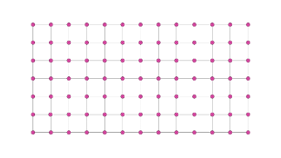

In [1]:
from IPython.display import Image
Image("image/random_walk.PNG")

Giả sử, ta đứng tại 1 điểm bất kì trên lưới, có tọa độ $(x_0, y_0)$. Ta có qui luật di chuyển như sau : Tung 2 đồng xu bất kì, có các kết quả :      
 - SS – đi lên trên 1 bước    
 - SN – đi xuống dưới 1 bước   
 - NS – đi sang phải 1 bước  
 - NN – đi sang trái 1 bước
 

Từ đây, ta có thể xây dựng được chuỗi Markov cho mô hình này. Không gian trạng thái của chuỗi chính là các trạng thái khả dĩ của hệ : $S = {s_1, s_2 ,…, s_{M*N}}$.     
Với ${s_k}$ là trạng thái k = M*i + j, người đang xét đứng tại ô (i,j). Dễ thấy, xác suất để người đứng tại ô (i,j) tại thời điểm t chuyển sang một ô lân cận trong thời điểm t + 1 chỉ phụ thuộc vào vị trí của người đó tại thời điểm t, không phụ thuộc vào vị trí người đó tại các thời điểm t-1, t-2,…


Ta có ma trận xác suất chuyển trạng thái được xây dựng như sau : 

P(g,h) =     
 - 1/4 nếu $\lvert({x_g} - {x_h})\rvert == 0$ && $\lvert({y_g} - {y_h})\rvert == 1$
 - 1/4 nếu $\lvert({x_g} - {x_h})\rvert == 1$ && $\lvert({y_g} - {y_h})\rvert == 0$   
 - 0 các trường hợp còn lại

### 2. Phương pháp Monte Carlo

#### a. Định nghĩa

Phương pháp Monte Carlo là phương pháp mô phỏng dựa vào lặp lại quá trình lấy mẫu ngẫu nhiên để thu được kết quả số. Phương pháp này được áp dụng vào các bài toán mà các phương pháp khác khó có thể đạt được kết quả. Đối với bài toán mô phỏng một hiện tượng vật lý ở ta đang xét ở đây, phương pháp này sử dụng với các hiện tượng mà độ tự do có hiện tượng ghép cặp. Tuy nhiên, ta không có định nghĩa cụ thể cho phương pháp này. Định nghĩa cụ thể phụ thuộc vào bài toán ta đang xét.   
Trong bài toán này, ta sẽ sử dụng thuật toán Metropolis–Hastings. Chi tiết trong thuật toán sẽ được giới thiệu trong chương sau, bởi vì định nghĩ tổng quát của thuật tương đối mơ hồ, gây khó hiểu cho người đọc.


#### b. Ví dụ

Do định nghĩa tổng quát của phương pháp Monte Carlo tương đối mơ hồ, ta sẽ ví dụ phương pháp này với bài toán tính số $\pi$

Xét hình tròn bán kính r đặt trong hình vuông có cạnh 2r như hình vẽ : 

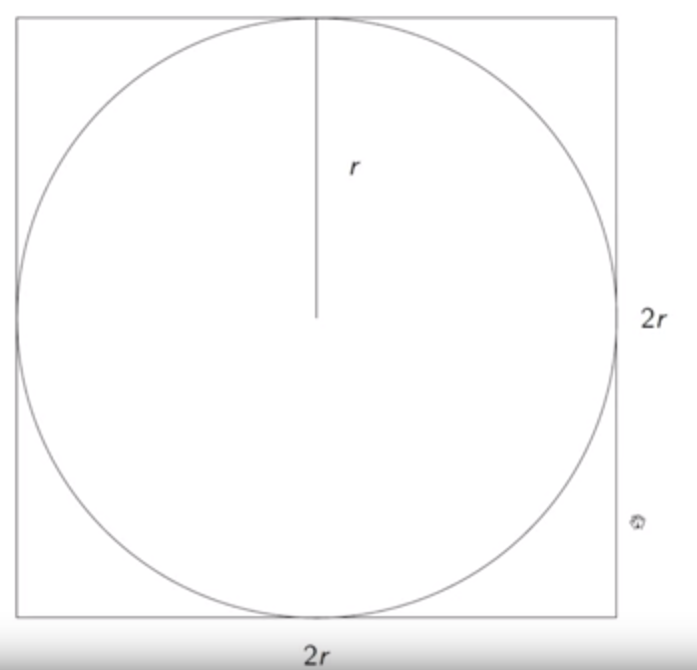

In [2]:
from IPython.display import Image
Image("image/circle_in_square.PNG")

Ta có :   
 - Diện tích hình tròn : $\pi$$r^{2}$   
 - Diện tích hình vuông : 4$r^{2}$

Nếu ta thả ngẫu nhiên một viên bi vào bên trong hình vuông, xác suất để viên bi rơi vào bên trong đường tròn là $\pi/4$    
Từ đây, ta có thuật toán tính $\pi$ như sau :    
 - Bước 1 : Thả ngẫu nhiên 1 viên bi vào bên trong hình vuông
 - Bước 2 : Đếm số viên bi rơi vào trong đường tròn = C
 - Bước 3 : Đếm số viên bi rơi vào trong hình vuông = K 
 - Bước 4 : Tính tỉ lệ R = C / K
 - Bước 5 : Lặp lại bước 1 đến 4 cho tới khi đạt được giá trị xấp xỉ của π mong muốn    
Ta có được 1 số kết quả như sau :  

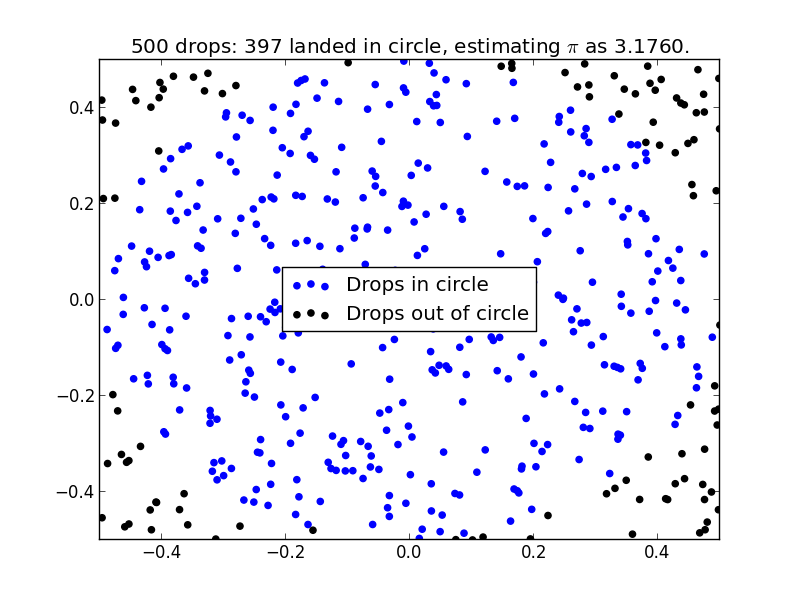

In [3]:
from IPython.display import Image
Image("image/500_drops.PNG")

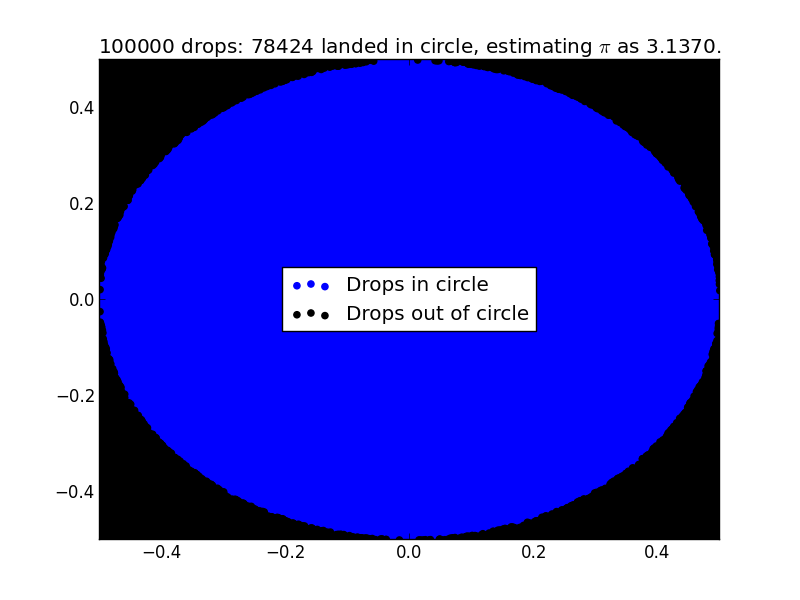

In [4]:
from IPython.display import Image
Image("image/100000_drops.PNG")

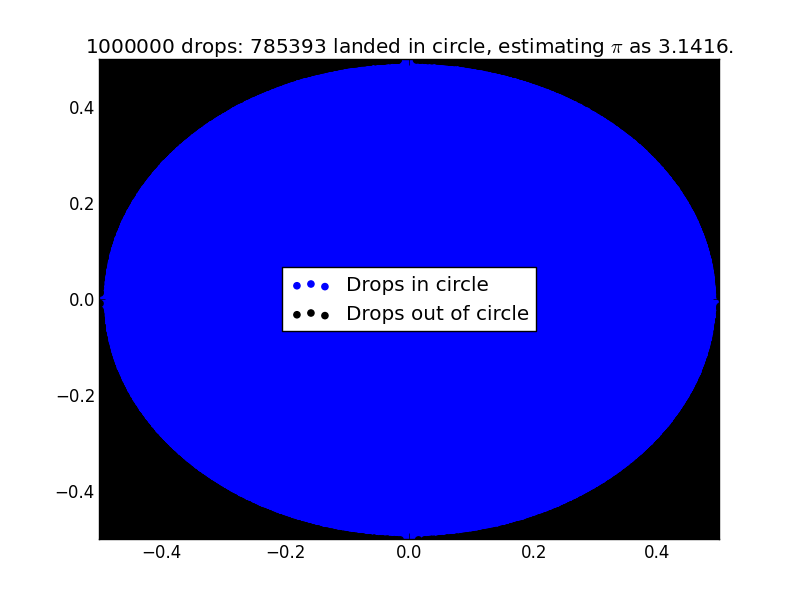

In [5]:
from IPython.display import Image
Image("image/1000000_drops.PNG")

# $\hspace{5.5cm}$ Chương 3 : Áp dụng với bài toán Ising

### 1. Mô hình Ising

Mô hình Ising được sử dụng để mô hình hóa lưới chữ nhật với các điểm nút biểu diễn các nguyên tử sắt từ. Các nguyen tử này có thể có giá trị +1 hoặc -1 tương ứng với spin từ up/down

Với các mô hình nhiều chiều hơn, ta cần xét tới quá trình chuyển pha tại nhiệt đọ Curie $T_c$ . Ở dưới nhiệt độ Curie $T_c$, vật liệu từ hoạt động bình thường. Trên nhiệt độ Curie $T_c$, năng lượng nhiệt phá vỡ các liên kết từ, vật liệu hoạt động như vật liệu thuận từ  thông thường

Nếu như không có từ trường từ bên ngoài, với tham số ghép cặp $J>0$, năng lượng từ quá trình từ hóa là : $$E = - J  
    \sum_{(atoms)} \sum_{(neighbor atoms)} (s_{atom}.s_{neighbor})$$

Viết gọn lại như sau : $$E = - J  \sum_{<i,j>}  (s_{i}.s_{j})$$
Mục tiêu của mô hình chính là xác định thâm số $T_c$. Ta sẽ chạy mô hình chuỗi Markov Monte Carlo với nhiều nhiệt độ khác nhau để xác định quá trình từ hóa như hàm của nhiệt độ.

Ví dụ quá trình từ hóa ở dưới và trên nhiệt độ từ hóa
Bên trái là từ hóa 100%, bên phải làn ko từ có từ hóa

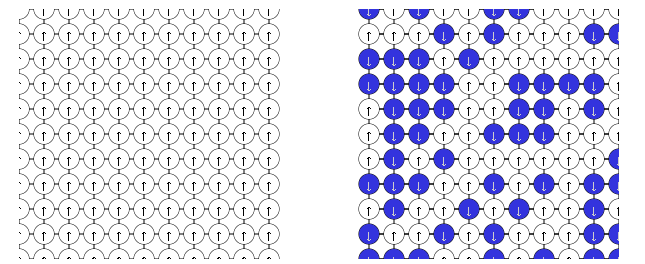

In [5]:
from IPython.display import Image
Image("image/spin_1.PNG")

Trong mô hình Ising, phân bố của spin trong lưới phu thuộc vào nhiệt độ và tuân theo phân bố Boltzmann:   
$\hspace{4cm}$   phân bố tần số ~ $e^{\frac{-E}{kT}}$    
trong đó, k là hằng số Boltzmann, T là nhiệt độ lưới và E là tổng năng lượng từ quá trình từ hóa

### 2. Mô phỏng mô hình Ising bằng cách tính toán điểm cân bằng từ hóa

#### a. Tính thô thiển

Tính thô thiên điểm cân bằng từ hòa của hệ thống bằng cách chạy vòng lặp qua tất cả các trạng thái có thể của hệ, tính toán năng lượng của hệ với điều kiện từ hóa, sau đó tính trung bình có trọng số dựa trên tần số của nó $e^{\frac{-E}{kT}}$

độ từ hóa trung bình  = $\sum_{(tất\hspace{1mm} cả \hspace{1mm} cấu \hspace{1mm} hình)} {độ \hspace{1mm} từ \hspace{1mm} hóa}. {tần \hspace{1mm} số \hspace{1mm} cấu \hspace{1mm} hình}$     
$ \hspace{3.5cm} = \sum_{(tất\hspace{1mm} cả \hspace{1mm} cấu \hspace{1mm} hình)} {độ \hspace{1mm} từ \hspace{1mm} hóa}.e^{\frac{-E}{kT}}$

#### b. Phương pháp Metropolis-Hasting 

Thay vì chọn các trạng thái 1 cách ngẫu nhiên, ta đánh trọng số chúng theo $  e^{\frac{-E}{kT}}$, sau đó ta chọn cấu hình với xác suất $  e^{\frac{-E}{kT}}$ và đánh trọng số tương ứng


Ta sẽ đi ngẫu nhiên qua không gian trạng thái, nhưng ta sẽ chạy đến các thạng thái dc thăm thường xuyên một cách thường xuyên hơn. Với mô hình Ising, ta biết các trạng thái spin tuân theo phấn phối Boltzmann :   
$\hspace{2cm}$phân phối tần số của các trạng thái    $ \sim   e^{\frac{-E}{kT}}$

Ta kí hiệu như sau :   
 - $x$ = cấu hình của lưới
 - $p$ = tần số phân bố của của cấu hình ( hàm phân bố trọng số)
 - $\tilde{T}$ = nhiệt độ không có thứ nguyên $\tilde{T} = \frac{kT}{J}$
 - $H(x)$ = tổng tất cả các spin lân cận $ \sum_{i,j} s_i s_i$ với cấu hình $x$

Từ đây ta có :   
$$p(x) \propto exp(-H(x)/\tilde{T}) = exp(- \frac{1}{\tilde{T}} \sum_{i,j} s_i s_j )  $$

Chú ý, đây chỉ là tỉ lệ, không phải là xác suất. Để tính được xác suất, ta cần chi cho tổng các cấu hình có thể xảy ra:   
$$p(x) = \frac{exp(-H(x)/\tilde{T})}{\sum_{all \hspace{1mm} x} exp(-H(x)/\tilde{T})}$$

Tuy nhiên, ta không tính được mẫu thức. Nhưng điều này không quá quan trọng với phương pháp chuỗi Markov Monte Carlo. Quá trình tính toán chỉ phụ thuộc vào $p(x)$ thông qua tỉ lệ $\frac{p(x^{'})}{p(x)}$, trong đó $x^{'}$ và $x$ là các điểm lấy mẫu. Vì vậy ta không cần hằng số chuẩn hóa (mẫu số).

#### d. Thuật toán :

1\. Chọn một cấu hình spin ban đầu $x$  
2\. Chọn một cấu hình spin mới $x^{'}$ 
3\. Lựa chọn ngẫu nhiên giữa đi sang cấu hình mới hoặc ở lại cấu hình cũ. Việc lựa chọn này được chọn theo tỉ lệ $\frac{p(x^{'})}{p(x)}$    
4\. Lặp lại bước 2 và 3 cho tới khi hệ hội tụ

Hàm phân phối xác suất cho biến $x$ là :  
$$p(x) = \frac{exp(-H(x)/\tilde{T})}{\sum_{all \hspace{1mm} x} exp(-H(x)/\tilde{T})}$$  
Ở bước 3, tỉ lệ được tính như sau :   
 $$\frac{p(x^{'})}{p(x)} =  \frac{exp(-H(x^{'})/\tilde{T})}{\sum_{all \hspace{1mm} x} exp(-H(x)/\tilde{T})} / \frac{exp(-H(x)/\tilde{T})}{\sum_{all \hspace{1mm} x} exp(-H(x)/\tilde{T})} $$  
  $$\frac{p(x^{'})}{p(x)} = \frac{exp(-H(x^{'})/\tilde{T})} {{exp(-H(x)/\tilde{T})}} $$  
   $$\frac{p(x^{'})}{p(x)} = exp(- \frac{H(x^{'}) - H(x)}{\tilde{T}})$$

Thuật toán để chuyển từ cấu hình $x$ sang cấu hình $x^{'}$ với tỉ lệ sau :   
$p(chuyển \hspace{1mm} sang \hspace{1mm} x^{'})$ = 

1 nếu $H(x^{'}) - H(x) < 0$ tương ứng với mức năng lượng thấp hơn

$exp(- \frac{H(x^{'}) - H(x)}{\tilde{T}})$ nếu $H(x^{'}) - H(x) >= 0$ tương ứng với mức năng lượng cao hơn

# $\hspace{5.5cm}$ Chương 4 : Lập trình cụ thể

### 1.Tạo hàm vẽ

Do đây là bài toán mô phỏng, vậy nên ta cần hàm vẽ để giúp ta dễ hình dung kết quả. Hàm vẽ này nhận đầu vào là dãy lưới spin, sau đó chuyển ra ảnh động biễu diễn quá trình mô phỏng

In [19]:
import numpy as np
from array2gif import write_gif


def to_two_color(lattice):
    blue = np.ones(lattice.shape, dtype=np.int) * 255 
    red = np.zeros(lattice.shape, dtype=np.int)
    red[lattice < 0] = 255 
    green = red 
    return np.array([red, green, blue])


def output_to_gif(dataset, filename, fps=8):
    print("Frames: {}".format(len(dataset)))
    colors = []
    write_gif(
        [to_two_color(lattice) for lattice in dataset],
        filename,
        fps=fps
    )

#### b. Cách xử lý tiêu chuẩn : 

Cách làm này tham khảo từ [5]:
Đầu tiên, ta cần xây dựng hàm tính toán biến thiên năng lượng :        
Hàm get_dH tính biến thiên năng lượng giữa 2 trạng thái $x$ và $x'$ $H(x^{'})- H(x) $. Bởi vì chỉ có vị trí $i,j$ thay đổi, ta chỉ cần tính sự thay đổi năng lượng ở vị trí này.

In [20]:
def get_dH(lattice, trial_location):
    """ H = - Sum_<ij>(s_i s_j) """
    i, j = trial_location
    height, width = lattice.shape
    H, Hflip = 0, 0
    for di, dj in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        ii = (i + di) % height
        jj = (j + dj) % width
        H -= lattice[ii, jj] * lattice[i, j]
        Hflip += lattice[ii, jj] * lattice[i, j]
    return Hflip - H

Sau đó, ta mô phỏng dựa vào biến thiên năng lượng đã tính ở trên.
Hàm standard_approach tạo ra lưới có các giá trị +1/-1 và lặp qua tất cả các trạng thái N * 5 lần, chụp lại hình ở lần thư 5

In [21]:
def standard_approach(T, width, height, N=60):
    # Randomly initialize the spins to either +1 or -1
    lattice = 2 * np.random.randint(2, size=(height, width)) - 1
    snapshots = []
    for snapshot in range(N):
        snapshots.append(to_two_color(lattice))
        print('{:2.0%} complete. Net magnetization: {:3.0%}'
              .format(snapshot / N,
                      abs(lattice.sum()) / lattice.size),
              end='\r')
        for step in range(5):
            # Walk through the array flipping atoms.
            for i in range(height):
                for j in range(width):
                    dH = get_dH(lattice, (i, j))
                    if dH < 0:  # lower energy: flip for sure
                        lattice[i, j] = -lattice[i, j]
                    else:  # Higher energy: flip sometimes
                        probability = np.exp(-dH / T)
                        if np.random.rand() < probability:
                            lattice[i, j] = -lattice[i, j]
    return snapshots

#### c. Cách xử lý dựa vào thư viện PyMC3 : 


Ta sẽ sử dụng phương pháp Metropolis-Hastings thư viện PyMC3 để cho mô hình Ising. Thư viện PyMC3 là gói thư viện lập trình xác suất được xây dựng nhàm mô phỏng chuỗi Markov Monter Carlo và nhiều loại suy diễn khác nhau như suy diễn Bayes,..    
Khi sử dụng PyMC3 ta cần xây dựng hàm get_H tính toán năng lượng $H(x)$ toàn bộ lưới, vì theo cách lập trình của PyMC3, mỗi bước hoàn toàn độc lập với bước tiếp theo. Điều này có nghĩa là ta không thể sử dụng thông tin ở trạng thái lưới trược đó để tính sự thay đổi về năng lượng get_dH, $H(x^{'}) - H(x)$

Trong trường hợp này, lưới tuân theo phấn phối Bernouli. Thế nên giá trị ở đây là {0, 1} chứ không phải là {-1, +1}. Vì vậy, ta có thể tạo thêm hàm to_spin, để chuyển về {-1, +1}. Sau đó, ta sẽ sử dụng hàm get_H tính toán năng lượng :

In [22]:
import theano
import theano.tensor as tt
import pymc3 as pm
from theano.compile.ops import as_op

# Fix compile failure on OSX
# https://stackoverflow.com/a/51312739
theano.config.gcc.cxxflags = "-Wno-c++11-narrowing"


def get_H(spins):
    H = - (
        tt.roll(spins, 1, axis=1) * spins +
        tt.roll(spins, 1, axis=0) * spins +
        tt.roll(spins, -1, axis=1) * spins +
        tt.roll(spins, -1, axis=0) * spins
    )
    return H


def to_spins(lattice):
    return 2 * lattice - 1


Thông thường, ta có thể sử dụng giá trị quan sát được để cập nhật ước tính tiên nghiệm của biến đang xét. Nhưng trong trường hợp này, biến được quan sát không có giá trị tiên nghiệm. Thay vào đó, thư viện này sử dụng pm.Potential. Hàm này sẽ trực tiếp thay đổi mức độ tương đòng để hướng dẫn quá trình bước ngẫu nhiên của chuỗi Markov Monte Carlo tới các cấu hình có năng lượng thấp hơn

Hàm mc3_approach sẽ mô phỏng chuỗi MCMC với PyMC3. Nó gần như tương tự với hàm standard_approach, trừ việc ta không thể nhảy theo từng vị trí như trước. Lần này, với mỗi bước ta sẽ tính lại với 1 lưới hoàn toàn mới. Vấn đề của cách tiếp cận này là, có nhiều cấu hình spins sẽ loại bỏ cấu hình khác. Điều này có nghĩa là thuật toán MCMC của chúng ta sẽ mất nhiều thời gian để hội tụ. Để xử lý vấn đề này, ta đặt tham số tỉ lệ scaling = .0006 để nhìn chúng chỉ có 1 vị trí trong lưới bị thay đổi.

In [23]:
def mc3_approach(T, width, height, N=100):
    shape = (height, width)
    x0 = np.random.randint(2, size=shape)
    with pm.Model() as model:
        x = pm.Bernoulli('x', 0.5, shape=shape, testval=x0)
        magnetization = pm.Potential(
            'm',
            -get_H(to_spins(x)) / T
        )
        scaling = .0006
        mul = int(height * width * 1.75)
        step = pm.BinaryMetropolis([x], scaling=scaling)
        trace = pm.sample(N * mul * 5, step=step, chains=1, tune=False)
    dataset = [to_two_color(2 * t['x'] - 1) for t in trace[::mul * 5]]
    # Print out the final percent magnetization
    lattice = 2 * trace[-1]['x'] - 1
    print('Finished. Net magnetization: {:3.0%}'
              .format(abs(lattice.sum()) / lattice.size))
    return dataset

#### d. Kết quả mô phỏng: 

In [ ]:
def run(T_over_Tc=.9, width=50, height=50, mc3=False):
    Tc = 2.269  # Normalized T := kT/J
    T = T_over_Tc * Tc
    dataset = None
    if mc3:
       dataset = mc3_approach(T, width, height, N=80)
       filename = ('mc3_ising_{}_{}x{}.gif'
                   .format(T_over_Tc, width, height))
    else:
       dataset = standard_approach(T, width, height, N=60)
       filename = ('ising_{}_{}x{}.gif'
                   .format(T_over_Tc, width, height))
    write_gif(dataset, filename, fps=8)

run(T_over_Tc=.75)
run(T_over_Tc=.75, mc3=True)
run(T_over_Tc=1.25)
run(T_over_Tc=1.25, mc3=True)

In [12]:
from IPython.display import HTML
HTML('<img src="image/ising_0.75_50x50_test.gif">')

In [13]:
from IPython.display import HTML
HTML('<img src="image/ising_1.25_50x50_test.gif">')

In [14]:
from IPython.display import HTML
HTML('<img src="image/mc3_ising_0.75_50x50_test.gif">')

In [15]:
from IPython.display import HTML
HTML('<img src="image/mc3_ising_1.25_50x50_test.gif">')

Trong bài tập lớn này, ta đã thực hiện được quá trình mổ phỏng mô hình Ising nhằm mô phỏng quá trình từ hóa trong sắt từ. Mô hình Ising là mô hình đơn giản, chỉ đúng với một số trường hợp từ hóa nhất định. Bài tập lớn này sử dụng 2 cách tiếp cận để mô phỏng mô hình.   
Với cách tiếp cận tiêu chuẩn, ta thấy tốc độ hội tụ nhanh hơn. Lý do là vì với cách tiếp cận tiêu chuẩn, ta chỉ "bước ngẫu nhiên" với từng điểm trên lưới. Còn trong cách tiếp cận dựa trên thư viện PyMC3, ta tạo hẳn lưới mới.   
Tất nhiên, với cả 2 cách tiếp cận, hệ vẫn đạt được quá trình từ hóa nếu nhiệt độ của hệ nhở hơn nhiệt độ tới hạn ($T$ = 0.75 $T_c$). Dù với cách tiếp cận sử dụng thư viện PyMC3, hệ khi ở nhiệt độ cao trong có vẻ ít hoạt động hơn hệ ở nhiệt độ thấp. Nhưng thực tế, mức độ từ hóa của cả 2 hệ đều gần bằng 0, do trong hệ có số lượng các điểm spin up và down bằng nhau.   
Sử dụng thư viện PyMC3 rất tốn bộ nhớ, cần phải sử dụng trên máy có 16Gb Ram mới có thể mô phỏng được với lưới 50x50. 
Ngoài ra, thư viện PyMC3 có thuật toán lấy mẫu No U-Turn và thuật toán Hamiltonian Monte Carlo cho phép đạt được tốc độ hội tụ cao hơn. 

# $\hspace{6.5cm}$ Tài liệu tham khảo

[1] Giovanni Gallavotti "Statistical Mechanics" :https://link.springer.com/book/10.1007%2F978-3-662-03952-6     
[2] Sheldon M Ross : "Stoschastic Process And Application" http://home.ustc.edu.cn/~alex2014/SPpdf/Stochastic%20Processes%20SM.pdf      
[3] Wikipedia : https://en.wikipedia.org/wiki/Markov_chain


[5]http://farside.ph.utexas.edu/teaching/329/lectures/node110.html     
https://docs.pymc.io/history.html